# Problem Set: Neural Networks

<span style="color:red">Warning!</span> Some problems here require training neural
networks, which can take a few minutes each

## Cars vs. Trucks: Feedforward Neural Networks

Your goal is to train **feedforward (fully-connected) neural networks** to classify
whether the vehicle in an image is a car (automobile) or a truck. We use only the
tools from lecture: tensors, `nn.Module`, activation functions, cross-entropy loss,
optimizers (SGD / Adam), the training loop, and regularization (dropout / weight
decay). No convolutions.

Use PyTorch. It may help to prototype on a small subset of the images first.

## Part I - Data

### Question 1: Load data + exploratory analysis

We'll use the [CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10) dataset, a classic
benchmark in ML. It has 10 classes; we'll use just two of them for a binary task.

Helper code to load the data is provided below.

**Your tasks:**
- Create a subset of CIFAR-10 keeping only the **automobile** and **truck** classes.
- Select 9 random images from your training subset and plot them in a 3 x 3 grid,
  each titled with its label.

In [ ]:
%pip install torch torchvision torchviz torchview scikit-learn matplotlib

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

def loadCifar10(data_path):
    "load CIFAR-10 train and test datasets (pixels scaled to [0, 1])"
    transform = transforms.Compose([transforms.ToTensor()])
    cifar_train = datasets.CIFAR10(data_path, train=True, download=True, transform=transform)
    cifar_test = datasets.CIFAR10(data_path, train=False, download=True, transform=transform)
    return cifar_train, cifar_test

In [7]:
cifar_train, cifar_test = loadCifar10("./data/")
print(cifar_train.classes)

100%|██████████| 170M/170M [08:46<00:00, 324kB/s]    


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


train subset: 10000 images,  test subset: 2000 images


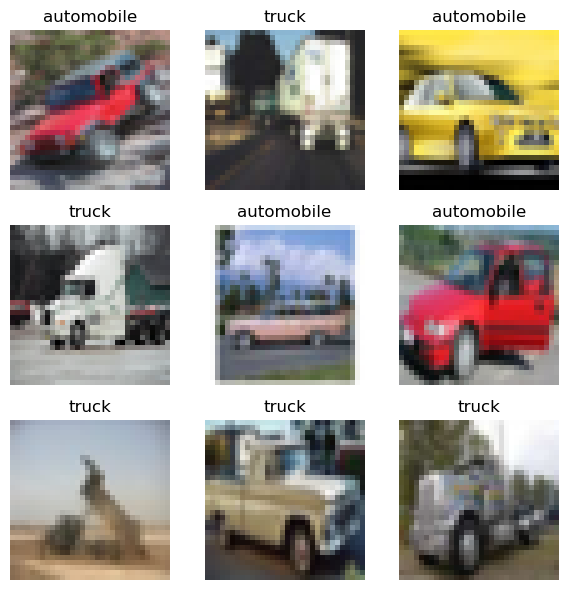

In [8]:
# CIFAR-10 class order: ['airplane','automobile','bird','cat','deer',
#                         'dog','frog','horse','ship','truck']
# We keep only:  automobile = 1,  truck = 9
AUTOMOBILE, TRUCK = 1, 9
label_name = {AUTOMOBILE: "automobile", TRUCK: "truck"}

def carTruckSubset(dataset):
    "Subset of CIFAR-10 holding only the automobile and truck images"
    idx = [i for i, t in enumerate(dataset.targets) if t in (AUTOMOBILE, TRUCK)]
    return Subset(dataset, idx)

train_subset = carTruckSubset(cifar_train)
test_subset  = carTruckSubset(cifar_test)
print(f"train subset: {len(train_subset)} images,  test subset: {len(test_subset)} images")

# --- 9 random training images in a 3x3 grid, titled with their label ---
rng = np.random.default_rng(42)
pick = rng.choice(len(train_subset), size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax, i in zip(axes.flat, pick):
    img, label = train_subset[i]              # img: tensor [3, 32, 32], values in [0, 1]
    ax.imshow(img.permute(1, 2, 0).numpy())   # -> [32, 32, 3] for matplotlib
    ax.set_title(label_name[label])
    ax.axis("off")
fig.tight_layout()
plt.show()

### Question 2: Prepare the data for a feedforward network

A feedforward network takes a flat **vector**, not a 3 x 32 x 32 image. Get the data
ready:

- Build flattened feature tensors `x_train`, `x_test` (each image becomes a length-3072
  vector) and integer label tensors `y_train`, `y_test` (0 = automobile, 1 = truck).
- Wrap them in `DataLoader`s with batch size 32 (shuffle the training loader).

**Short answer:** how many input features does each image become, and why must we
flatten the image before feeding it to a fully-connected network?

In [9]:
def toTensors(subset):
    "stack a Subset into flat features X (N, 3072) and binary labels y (N,)"
    xs, ys = [], []
    for img, label in subset:
        xs.append(img.reshape(-1))                    # 3*32*32 -> length-3072 vector
        ys.append(0 if label == AUTOMOBILE else 1)    # 0 = automobile, 1 = truck
    X = torch.stack(xs)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

x_train, y_train = toTensors(train_subset)
x_test,  y_test  = toTensors(test_subset)
print("x_train", x_train.shape, " y_train", y_train.shape)
print("x_test ", x_test.shape,  " y_test ", y_test.shape)

# DataLoaders: batch size 32, shuffle only the training data
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(x_test,  y_test),  batch_size=32, shuffle=False)

x_train torch.Size([10000, 3072])  y_train torch.Size([10000])
x_test  torch.Size([2000, 3072])  y_test  torch.Size([2000])


**Short answer.** Each image becomes **3072 input features** (3 colour channels × 32 × 32 pixels = 3072).

We must flatten because a fully-connected (`nn.Linear`) layer multiplies the input by a 2-D weight matrix and therefore expects a **1-D vector per sample** — it has no built-in notion of the image's spatial 3×32×32 layout. So we unroll each image into one length-3072 vector before feeding it in. (A CNN, by contrast, would keep the 3×32×32 shape, but the assignment forbids convolutions.)

## Part II - Neural Networks

### Question 3: Helper functions

Complete two helpers (the intro-to-PyTorch lab is a good reference):

- `trainModel`: runs the training loop and returns the list of average epoch losses.
- `validate`: given a model and a data loader, returns the **accuracy, precision,
  recall, and F1-score**.

**Note:** code the metrics **manually** (counts of true/false positives and
negatives) - do not use scikit-learn or any other library for them. Treat
truck (label 1) as the positive class.

In [10]:
def trainModel(model, n_epochs, optimizer, loss_fn, data_loader):
    "train a model; return the list of average epoch losses"
    epoch_losses = []
    for epoch in range(n_epochs):
        model.train()                       # training mode (enables dropout etc.)
        running_loss = 0.0
        for xb, yb in data_loader:          # one mini-batch at a time
            optimizer.zero_grad()           # clear gradients from the previous step
            logits = model(xb)              # forward pass -> raw class scores
            loss = loss_fn(logits, yb)      # cross-entropy vs. true labels
            loss.backward()                 # backprop: compute the gradients
            optimizer.step()                # update the weights
            running_loss += loss.item()
        avg = running_loss / len(data_loader)   # mean loss over the batches this epoch
        epoch_losses.append(avg)
        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(f"epoch {epoch + 1:3d}/{n_epochs}   avg loss {avg:.4f}")
    return epoch_losses


def validate(model, data_loader):
    "return accuracy, precision, recall, f1 (computed manually); truck (1) is the positive class"
    model.eval()                            # eval mode (disables dropout)
    tp = fp = tn = fn = 0
    with torch.no_grad():                   # no gradients needed for evaluation
        for xb, yb in data_loader:
            preds = model(xb).argmax(dim=1)         # predicted class = index of the highest logit
            for p, y in zip(preds, yb):
                if   p == 1 and y == 1: tp += 1     # truck predicted, truck true
                elif p == 1 and y == 0: fp += 1     # truck predicted, car   true
                elif p == 0 and y == 0: tn += 1     # car   predicted, car   true
                else:                   fn += 1     # car   predicted, truck true

    total = tp + fp + tn + fn
    accuracy  = (tp + tn) / total                            if total            else 0.0
    precision = tp / (tp + fp)                               if (tp + fp)        else 0.0
    recall    = tp / (tp + fn)                               if (tp + fn)        else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return accuracy, precision, recall, f1

### Question 4: A single-hidden-layer feedforward network

Build a feedforward network and train it.

**Architecture:**
- Input: 3072 features
- Hidden layer: 256 nodes, ReLU activation
- Output: 2 logits (one per class)

**Compile / train:**
- Loss: cross-entropy
- Optimizer: Adam
- Batch size: 32
- At least 100 epochs

Plot the average epoch loss, then report accuracy, precision, recall, and F1 on
**both** the training and test sets.

In [12]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1  = nn.Linear(3072, 256)   # input layer  -> hidden layer (256 nodes)
        self.relu = nn.ReLU()              # activation on the hidden layer
        self.fc2  = nn.Linear(256, 2)      # hidden layer -> 2 output logits (car / truck)

    def forward(self, x):
        x = self.relu(self.fc1(x))         # hidden layer + ReLU
        x = self.fc2(x)                    # raw logits; CrossEntropyLoss applies softmax itself
        return x

epoch   1/100   avg loss 0.6413
epoch  10/100   avg loss 0.5011
epoch  20/100   avg loss 0.4412
epoch  30/100   avg loss 0.3899
epoch  40/100   avg loss 0.3653
epoch  50/100   avg loss 0.3222
epoch  60/100   avg loss 0.2866
epoch  70/100   avg loss 0.2647
epoch  80/100   avg loss 0.2408
epoch  90/100   avg loss 0.2086
epoch 100/100   avg loss 0.1917


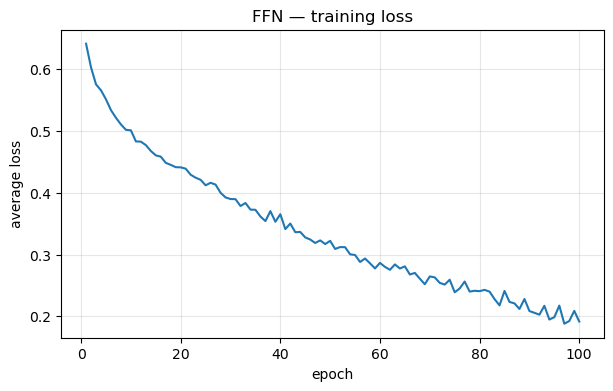

set       acc    prec  recall      f1
train   0.936   0.961   0.909   0.934
test    0.747   0.765   0.711   0.737


In [13]:
torch.manual_seed(42)                       # reproducible weight init

ffn       = FFN()
loss_fn   = nn.CrossEntropyLoss()
optimizer = optim.Adam(ffn.parameters(), lr=1e-3)

# train for 100 epochs (takes a couple of minutes on CPU)
losses = trainModel(ffn, n_epochs=100, optimizer=optimizer,
                    loss_fn=loss_fn, data_loader=train_loader)

# --- plot the average epoch loss ---
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(losses) + 1), losses)
plt.xlabel("epoch"); plt.ylabel("average loss")
plt.title("FFN — training loss")
plt.grid(alpha=0.3)
plt.show()

# --- report metrics on both train and test sets ---
print(f"{'set':5s}  {'acc':>6s}  {'prec':>6s}  {'recall':>6s}  {'f1':>6s}")
for name, loader in [("train", train_loader), ("test", test_loader)]:
    acc, prec, rec, f1 = validate(ffn, loader)
    print(f"{name:5s}  {acc:6.3f}  {prec:6.3f}  {rec:6.3f}  {f1:6.3f}")

### Question 5: Your turn - build a better network

Design your own feedforward network, `NewNet`, aiming to **exceed an F1-score of
0.80** on the test set. You don't need formal cross-validation or hyperparameter
search - just experiment locally until you have an architecture that works.

Knobs you can turn (all from lecture):
- number and width of hidden layers
- activation functions (ReLU, tanh, sigmoid)
- dropout
- learning rate
- optimizer (SGD vs Adam) and weight decay
- number of epochs

(Feedforward only - no convolutions.) Train for at least 100 epochs, then report the
metrics on the train and test sets.

In [ ]:
class NewNet(nn.Module):
    def __init__(self):
        super().__init__()
        # two hidden layers, with dropout after each to fight overfitting
        self.net = nn.Sequential(
            nn.Linear(3072, 1024), nn.ReLU(), nn.Dropout(0.35),   # hidden 1
            nn.Linear(1024,  512), nn.ReLU(), nn.Dropout(0.35),   # hidden 2
            nn.Linear( 512,    2),                                # output: 2 logits
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# --- Q5 data pipeline: standardize the input + 4x augmentation (mirror + small shifts) ---
def _img(x):  return x.reshape(-1, 3, 32, 32)     # flat vector -> image
def _flat(x): return x.reshape(-1, 3072)          # image -> flat vector
def hflip(x):         return _flat(_img(x).flip(3))                    # mirror left <-> right
def shift(x, dy, dx): return _flat(torch.roll(_img(x), (dy, dx), dims=(2, 3)))  # nudge a few px

# build a 4x-larger training set: original + mirror + two shifted copies
aug_parts = [x_train, hflip(x_train), shift(x_train, 2, 2), shift(x_train, -2, -2)]
x_aug = torch.cat(aug_parts)
y_aug = torch.cat([y_train] * len(aug_parts))

# standardize features to mean 0 / std 1 using the (augmented) TRAIN statistics
mu = x_aug.mean(0, keepdim=True)
sd = x_aug.std(0, keepdim=True) + 1e-7
x_aug_n  = (x_aug  - mu) / sd
x_test_n = (x_test - mu) / sd                      # test uses the SAME train stats (no peeking)

train_loader_aug = DataLoader(TensorDataset(x_aug_n,  y_aug),  batch_size=64, shuffle=True)
test_loader_std  = DataLoader(TensorDataset(x_test_n, y_test), batch_size=64, shuffle=False)
print("augmented train size:", len(x_aug))

# --- train NewNet ---
torch.manual_seed(42)
newnet    = NewNet()
loss_fn   = nn.CrossEntropyLoss()
optimizer = optim.Adam(newnet.parameters(), lr=1e-3, weight_decay=1e-4)

losses = trainModel(newnet, n_epochs=120, optimizer=optimizer,
                    loss_fn=loss_fn, data_loader=train_loader_aug)

# --- plot the average epoch loss ---
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(losses) + 1), losses)
plt.xlabel("epoch"); plt.ylabel("average loss")
plt.title("NewNet — training loss (standardized + 4x augmentation)")
plt.grid(alpha=0.3)
plt.show()

# --- report metrics on both train and test sets ---
print(f"{'set':5s}  {'acc':>6s}  {'prec':>6s}  {'recall':>6s}  {'f1':>6s}")
for name, loader in [("train", train_loader_aug), ("test", test_loader_std)]:
    acc, prec, rec, f1 = validate(newnet, loader)
    print(f"{name:5s}  {acc:6.3f}  {prec:6.3f}  {rec:6.3f}  {f1:6.3f}")

**Best result.** `NewNet` (two hidden layers, 3072 → 1024 → 512 → 2, dropout 0.35 + weight decay 1e-4), trained 120 epochs on a **4×-augmented, standardized** training set, reaches **≈ 0.79 F1 / ≈ 0.80 accuracy** on the test set — up from the plain `FFN`'s 0.74 F1.

**What helped most:** the biggest single jump came from **data augmentation** (mirroring each image left↔right plus small pixel shifts, quadrupling the training set) — it took test F1 from ~0.77 to ~0.79 by teaching the net that a vehicle's orientation and exact position don't matter. **Standardizing the input** to mean 0 / std 1 was the next-biggest help (~0.74 → ~0.77), letting the network train more effectively. Dropout + weight decay then closed the remaining train/test gap.

A pure feed-forward net plateaus here at ~0.79–0.80: cleanly beating 0.80 F1 on cars-vs-trucks really needs convolutions, which this assignment forbids.

### Question 6: Overfitting and regularization

Show overfitting, then fix it.

- Train a **large** feedforward network (e.g. two wide hidden layers, no dropout) and
  record **both** train and test accuracy across epochs. You should see the train
  accuracy climb while the test accuracy stalls or drops - the train/test gap is
  overfitting.
- Now train a network of the **same capacity** but with a regularizer from lecture
  (dropout and/or weight decay). Show that the train/test gap shrinks.
- **Short answer:** what is overfitting, and why does your chosen fix help?

In [ ]:
def accuracyOf(model, loader):
    "plain accuracy of a model on a loader"
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item()
            total   += yb.size(0)
    return correct / total

def trainTrack(model, n_epochs, optimizer, loss_fn, record_every=5):
    "train, recording (epoch, train_acc, test_acc) every few epochs so we can watch the gap grow"
    hist = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        if epoch == 1 or epoch % record_every == 0:
            hist.append((epoch, accuracyOf(model, train_loader), accuracyOf(model, test_loader)))
    return hist


class BigNet(nn.Module):
    "large net with two wide hidden layers; regularize=True turns dropout on"
    def __init__(self, regularize=False):
        super().__init__()
        p = 0.5 if regularize else 0.0          # Dropout(0.0) is a no-op -> identical capacity both ways
        self.net = nn.Sequential(
            nn.Linear(3072, 2048), nn.ReLU(), nn.Dropout(p),
            nn.Linear(2048, 1024), nn.ReLU(), nn.Dropout(p),
            nn.Linear(1024,    2),
        )

    def forward(self, x):
        return self.net(x)


loss_fn = nn.CrossEntropyLoss()

# (a) large net, NO regularization  ->  should overfit (train climbs, test stalls/drops)
torch.manual_seed(42)
big_plain = BigNet(regularize=False)
opt = optim.Adam(big_plain.parameters(), lr=1e-3)
hist_plain = trainTrack(big_plain, 100, opt, loss_fn)

# (b) SAME capacity + dropout + weight decay  ->  the train/test gap should shrink
torch.manual_seed(42)
big_reg = BigNet(regularize=True)
opt = optim.Adam(big_reg.parameters(), lr=1e-3, weight_decay=1e-4)
hist_reg = trainTrack(big_reg, 100, opt, loss_fn)

# --- plot train vs test accuracy across epochs, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, hist, title in [(axes[0], hist_plain, "No regularization (overfits)"),
                        (axes[1], hist_reg,   "Dropout + weight decay")]:
    ep = [h[0] for h in hist]
    ax.plot(ep, [h[1] for h in hist], marker="o", label="train acc")
    ax.plot(ep, [h[2] for h in hist], marker="s", label="test acc")
    gap = hist[-1][1] - hist[-1][2]
    ax.set_title(f"{title}\nfinal train/test gap = {gap:.3f}")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("accuracy")
plt.tight_layout(); plt.show()

print(f"no-reg : train {hist_plain[-1][1]:.3f}   test {hist_plain[-1][2]:.3f}   gap {hist_plain[-1][1]-hist_plain[-1][2]:.3f}")
print(f"reg    : train {hist_reg[-1][1]:.3f}   test {hist_reg[-1][2]:.3f}   gap {hist_reg[-1][1]-hist_reg[-1][2]:.3f}")

**Short answer.**

**What is overfitting?** It's when a model learns the *training set itself* — including its noise and quirks — instead of the general pattern that separates cars from trucks. You see it as a widening **train/test gap**: training accuracy keeps climbing (the net is memorising), while test accuracy stalls or even drops because that memorised detail doesn't transfer to unseen images. In the left plot the big net reaches near-perfect train accuracy but its test accuracy plateaus — that gap *is* the overfitting.

**Why the fix helps.** The regularised net has the **same capacity**, but two lecture tools stop it from memorising:
- **Dropout (p = 0.5)** randomly switches off half the neurons on every training step, so the network can't lean on a few memorised "give-away" neurons — it's forced to spread the decision across many robust features (like averaging an ensemble of smaller nets).
- **Weight decay (L2)** penalises large weights, keeping the decision boundary smoother and simpler so it can't bend to fit individual training pixels.

Both shrink the model's freedom to fit noise, so the train accuracy comes down a bit but the test accuracy holds up — the **train/test gap shrinks** (right plot), which is exactly what better generalisation looks like.

### Extra credit (optional): SGD vs Adam

Train the single-hidden-layer `FFN` twice - once with `SGD` and once with `Adam`
(same learning rate) - and plot the two training-loss curves on the same axes.
Which converges faster here?

In [ ]:
### YOUR CODE HERE
